In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

data_dir = Path.cwd()
ecg = pd.read_csv(data_dir / "103_ekg.csv")
annotation = pd.read_csv(data_dir / "103_annotations_1.csv")

display(ecg.head())
display(annotation.head())

,Unnamed: 0,MLII,V2,symbol
0,0,-0.375,0.05,NaN
1,1,-0.375,0.05,NaN
2,2,-0.375,0.05,NaN
3,3,-0.375,0.05,NaN
4,4,-0.375,0.05,NaN


,index,annotation_symbol
0,21,+
1,265,N
2,575,N
3,876,N
4,1180,N


In [3]:
print ("ecg shape", ecg.shape)
print("ecg annotation", ecg.columns.tolist())

print(annotation.shape)
print(annotation.columns.tolist())

ecg shape (650000, 4)
ecg annotation ['Unnamed: 0', 'MLII', 'V2', 'symbol']
(2091, 2)
['index', 'annotation_symbol']


In [4]:
# Make the first column available as 'index' regardless of how pandas named it
if 'index' not in ecg.columns:
    ecg = ecg.rename(columns={col: 'index' for col in ecg.columns if str(col).strip().lower() in {'unnamed: 0', 'unnamed:0', 'unnamed 0', 'unnamed'}})

# If pandas did not create a usable index column, create one explicitly
if 'index' not in ecg.columns:
    ecg.insert(0, 'index', range(len(ecg)))

ecg_smaples = len(ecg)
fs = 360
print('index prepared successfully!!')

index prepared successfully!!


In [5]:
duration_sec= len(ecg)/fs
duration_min= duration_sec/60
print(f'total samples: {len(ecg)}')
print('duration in seconds', f'{duration_sec:.2f}')
print('duration in minutes', f'{duration_min:.2f}')

total samples: 650000
duration in seconds 1805.56
duration in minutes 30.09


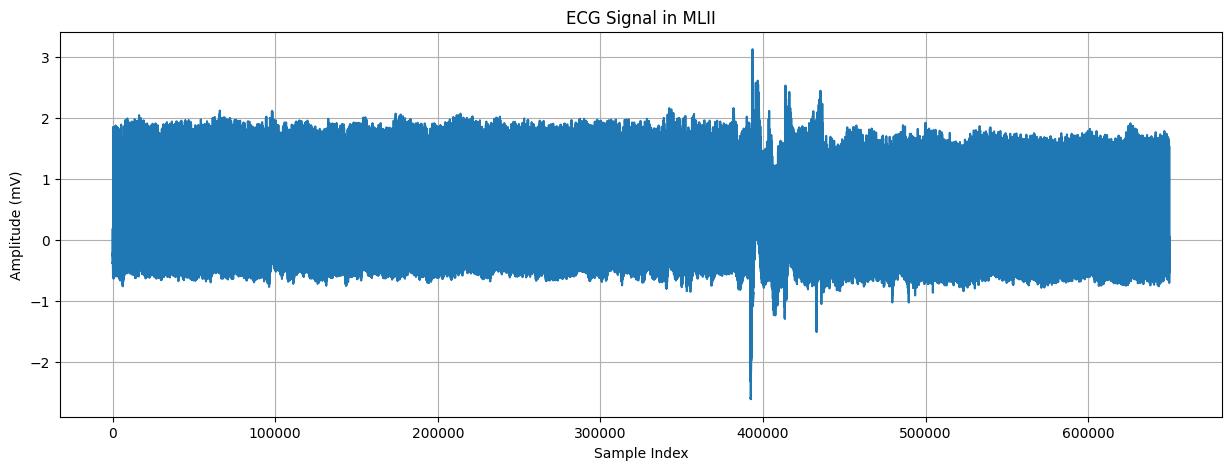

In [6]:
plt.figure(figsize=(15,5))
plt.plot( ecg['MLII'])
plt.title('ECG Signal in MLII')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.show()

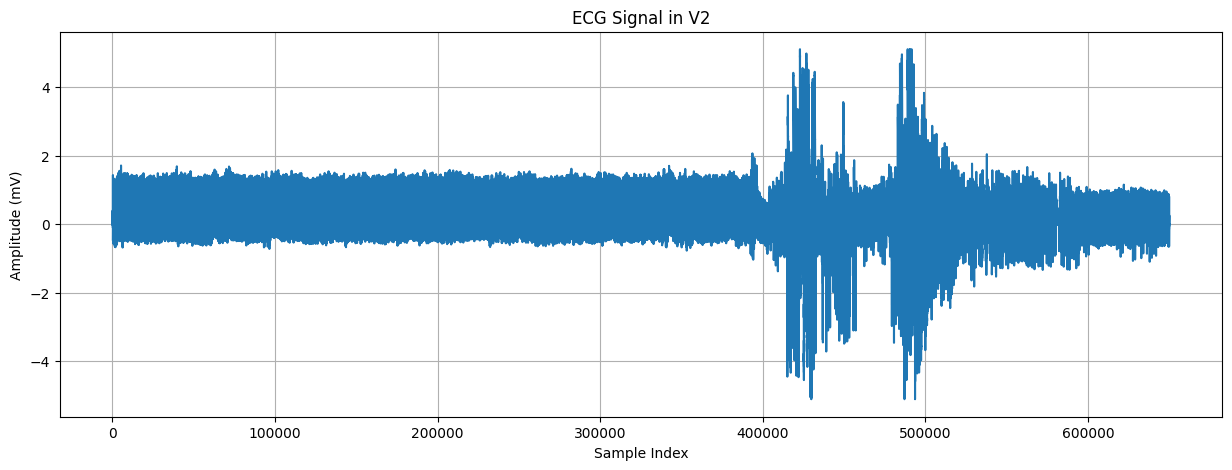

In [7]:
plt.figure(figsize=(15,5))
plt.plot( ecg['V2'])
plt.title('ECG Signal in V2')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.show()

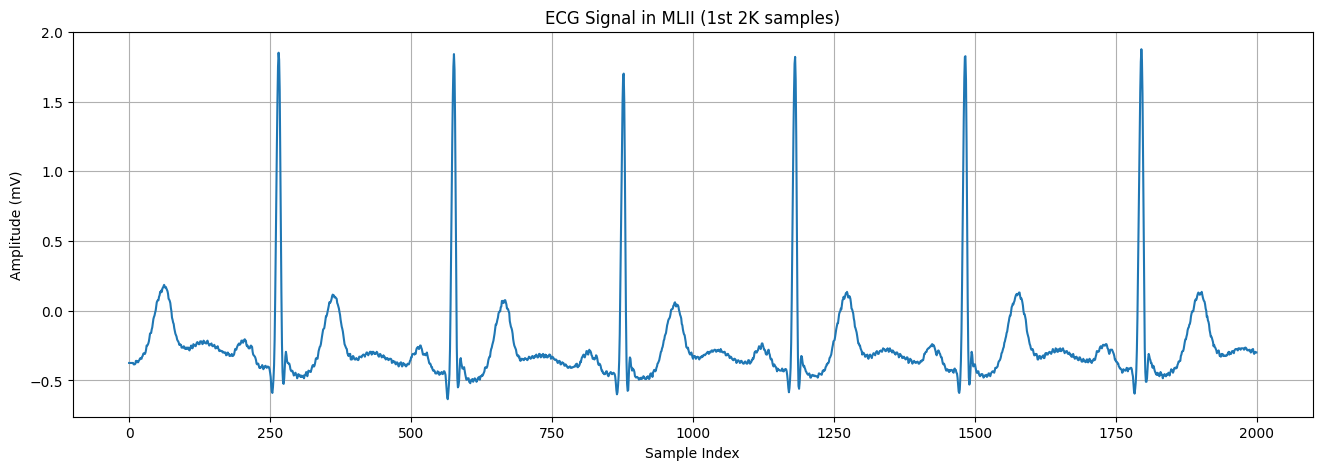

In [8]:
start=0
end=2000
plt.figure(figsize=(16,5))
plt.plot(ecg['index'][start:end], ecg['MLII'][start:end])
plt.title('ECG Signal in MLII (1st 2K samples)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.show()


In [9]:
print(annotation.head(10))


   index annotation_symbol
0     21                 +
1    265                 N
2    575                 N
3    876                 N
4   1180                 N
5   1482                 N
6   1795                 N
7   2127                 N
8   2444                 N
9   2744                 N


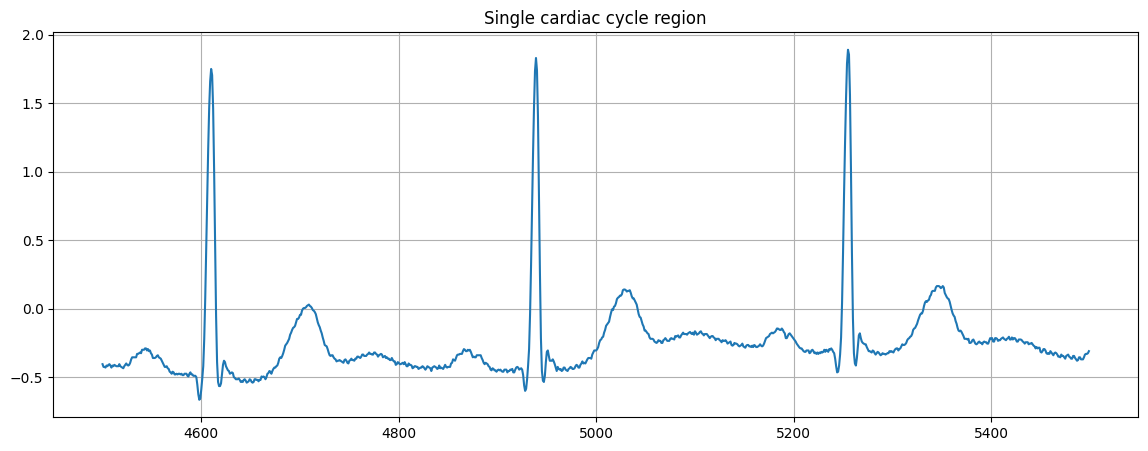

In [10]:
sample_no=5000
window=500
plt.figure(figsize=(14,5))
plt.plot(ecg['index'][sample_no-window:sample_no+window], ecg['MLII'][sample_no-window:sample_no+window])
plt.title('Single cardiac cycle region')
plt.grid(True)
plt.show()

In [11]:
merged = pd.merge(ecg, annotation, how='left', on='index')
print('merged_shape', merged.shape)
display(merged.head())

merged_shape (650000, 5)


,index,MLII,V2,symbol,annotation_symbol
0,0,-0.375,0.05,NaN,NaN
1,1,-0.375,0.05,NaN,NaN
2,2,-0.375,0.05,NaN,NaN
3,3,-0.375,0.05,NaN,NaN
4,4,-0.375,0.05,NaN,NaN


In [12]:
annotated_data= pd.merge(ecg, annotation, how='inner', on='index')
print('annotated_data shape', annotated_data.shape)

annotated_data shape (2091, 5)


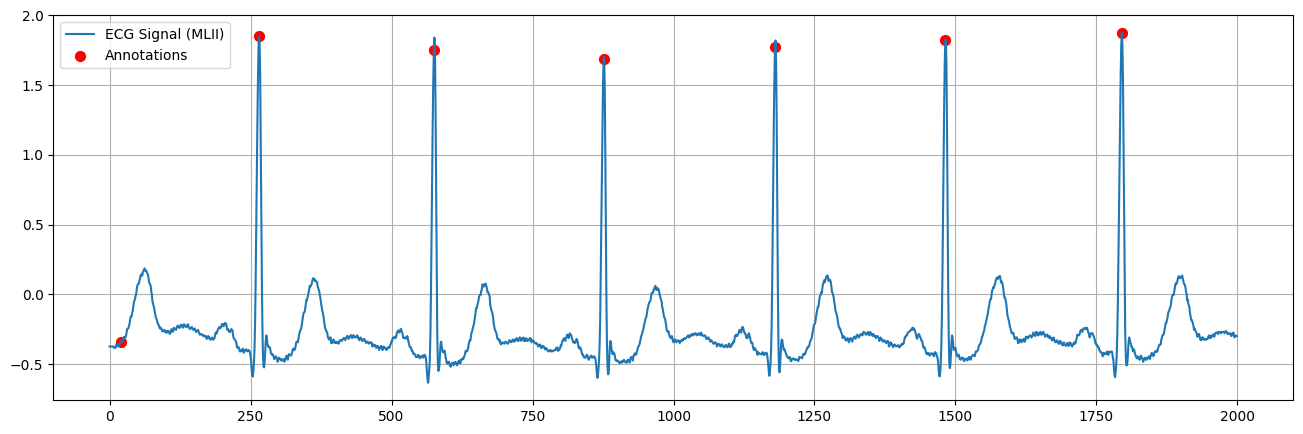

In [13]:
segment = merged.iloc[:2000]
ann_points = segment[segment['annotation_symbol'].notna()]
plt.figure(figsize=(16,5))
plt.plot(segment['index'], segment['MLII'], label='ECG Signal (MLII)')
plt.scatter(ann_points['index'], ann_points['MLII'], color='red', label='Annotations', s=50)
plt.legend()
plt.grid(True)
plt.show()

In [14]:
annotation_counts = merged['annotation_symbol'].value_counts()
print(annotation_counts)

annotation_symbol
N    2082
~       6
A       2
+       1
Name: count, dtype: int64


In [15]:
normal_beats=annotated_data[annotated_data['annotation_symbol']=='N']
print('normal beats number', len(normal_beats))

normal beats number 2082


In [16]:
beat_location=normal_beats['index'].values
rr_samples = np.diff(beat_location)
rr_seconds = rr_samples / fs
print('1st 10RR intervals in seconds', rr_seconds[:10])

1st 10RR intervals in seconds [0.86111111 0.83611111 0.84444444 0.83888889 0.86944444 0.92222222
 0.88055556 0.83333333 0.83333333 0.84166667]


In [17]:
mean_rr = np.mean(rr_seconds)
heart_rate_bpm = 60 / mean_rr
print(f'Average heart rate: {heart_rate_bpm:.2f} bpm')
print(f'mean rr interval in seconds: {mean_rr:.3f} sec')

Average heart rate: 69.19 bpm
mean rr interval in seconds: 0.867 sec
